# Notebook 05 — Monte Carlo Validation of the Optimal Strategy

**Paper**: Guéant, O. (2017). *Optimal Market Making*.  
**Status**: This notebook is **not in the paper** — it is an extension that validates the ODE-derived strategy by simulation.

**Figures produced**:

| Figure | Content |
|--------|---------|
| A | Histogram of terminal P&L — optimal vs naive |
| B | Sample trajectory — price, inventory, MtM |
| C | $\mathbb{E}[\lvert\text{inventory}\rvert]$ and $\text{std}(\text{inventory})$ over time |

---

## Motivation

Notebooks 01–04 solve the **theoretical** optimal quotes via ODE (Eq. 3.9). But:
1. Does the strategy **actually** generate profit when simulated with realistic Poisson fills and Brownian price paths?
2. How does it compare to a **naive** strategy (fixed symmetric spread, no inventory skewing)?
3. Does the optimal strategy successfully **control inventory** as the theory predicts?

This notebook answers all three by running $N_{\text{sim}} = 2000$ Monte Carlo trajectories.


## 1. Simulation mechanics

### 1.1 What the simulator does

At each discrete time step $t \to t + dt$:

1. **Price update**: $S_{t+dt} = S_t + \sigma \sqrt{dt} \cdot Z$, where $Z \sim \mathcal{N}(0,1)$.

2. **Quote lookup**: Given current inventory $n$ and time $t$, read $\delta^b(t, n)$ and $\delta^a(t, n)$ from the pre-computed ODE solution. Bid price = $S_t - \delta^b$, ask price = $S_t + \delta^a$.

3. **Fill simulation**: Each side has Poisson intensity $\Lambda(\delta) = A \, e^{-k\delta}$.
   - $\text{Prob}(\text{bid fill in } [t, t+dt]) \approx A \, e^{-k\delta^b} \cdot dt$
   - Draw $U \sim \text{Uniform}(0,1)$; fill if $U < \text{prob}$.

4. **Cash & inventory update** on fill:
   - Bid fill: $n \leftarrow n + 1$, $X \leftarrow X - (S - \delta^b) \cdot \Delta$
   - Ask fill: $n \leftarrow n - 1$, $X \leftarrow X + (S + \delta^a) \cdot \Delta$

5. **Mark-to-market**: $\text{MtM}_t = X_t + n_t \cdot \Delta \cdot S_t$.

6. **Terminal P&L**: $\text{P\&L} = X_T + n_T \cdot \Delta \cdot S_T$ (no terminal penalty, $\ell \equiv 0$).

### 1.2 The two strategies compared

| Strategy | Bid quote $\delta^b$ | Ask quote $\delta^a$ | Inventory-dependent? |
|----------|---------------------|---------------------|---------------------|
| **Optimal** | $\delta^b(t, n)$ from ODE | $\delta^a(t, n)$ from ODE | ✅ Yes — skews with $n$ |
| **Naive** | $\delta^b(0, 0) = \delta^a(0, 0)$ (fixed) | Same constant | ❌ No — ignores inventory |

The naive strategy uses the optimal half-spread at $n = 0$ (symmetric, mid-inventory) but **never adjusts** for inventory. This isolates the **value of inventory skewing**.

### 1.3 What to expect

- **P&L**: Optimal should have similar or higher mean, but **lower variance** (risk-adjusted).
- **Inventory**: Optimal should hover closer to 0 (mean-reversion via skew). Naive should drift.
- **Fills**: Naive may get more fills (symmetric spread is sometimes tighter), but takes more risk.


## 2. Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

import sys
sys.path.append(str(Path().resolve().parents[0]))

from market_making.params.assets import IG, GAMMA, T
from market_making.core.solver_1d import solve_general
from market_making.simulation.simulator import simulate_1d, simulate_naive
from market_making.core.closed_form import approx_quotes

plt.style.use("seaborn-v0_8")
%matplotlib inline

In [3]:
N_SIM = 2000
N_T = 7200

## 4. Solve the ODE and extract the quote lookup table

The simulator needs the full $(N_t + 1) \times (2Q + 1)$ quote arrays $\delta^b(t, n)$ and $\delta^a(t, n)$ from the ODE solution. At each simulation step, it reads the quote for the current time and inventory level.


In [4]:
print("Solving ODE (IG, Model A) ...")
t0 = time.time()
sol = solve_general(IG, GAMMA, T, xi=GAMMA, N_t=N_T)
print(f"  Done in {time.time()-t0:.1f} s")

Q = int(IG["Q"])
print(f"  Quote table shape: {sol['delta_bid'].shape}  "
      f"= ({N_T+1} time steps × {2*Q+1} inventory levels)")

# The naive strategy uses δ*(0,0) as a fixed half-spread
half_spread_naive = sol["delta_bid"][0, Q]  # t=0, n=0
print(f"  Naive half-spread = δ^b(0, n=0) = {half_spread_naive:.6e}")

# Fill probability at the naive spread
fill_prob = IG["A"] * np.exp(-IG["k"] * half_spread_naive) * (T / N_T)
print(f"  Fill prob/step at naive spread = {fill_prob:.4e}")
print(f"  Expected fills/side over T ≈ {fill_prob * N_T:.1f}")


Solving ODE (IG, Model A) ...
  Done in 4.7 s
  Quote table shape: (7201, 9)  = (7201 time steps × 9 inventory levels)
  Naive half-spread = δ^b(0, n=0) = 1.208206e-04
  Fill prob/step at naive spread = 1.0466e-04
  Expected fills/side over T ≈ 0.8


## 5. Run Monte Carlo simulations

The two simulations are run with the same seed, so they are based on the same random initialization and comparable Monte Carlo settings. The Brownian price shocks are generated in the same way in both simulations, although the execution randomness differs because the two strategies quote differently.


1. **Optimal**: quotes read from the ODE solution → inventory-dependent skewing.
2. **Naive**: fixed symmetric spread = $\delta^b(0, 0)$ for all $t$ and $n$.

The simulator uses a thinning/acceptance approach: at each step, draw $U \sim \text{Uniform}(0,1)$ and fill if $U < \Lambda(\delta) \cdot dt$.


In [5]:
print(f"Simulating {N_SIM} OPTIMAL trajectories ...")
t0 = time.time()
res_opt = simulate_1d(sol, IG, GAMMA, T, N_sim=N_SIM, seed=42)
print(f"  Done in {time.time()-t0:.1f} s")

print(f"Simulating {N_SIM} NAIVE trajectories ...")
t0 = time.time()
res_naive = simulate_naive(IG, GAMMA, T, half_spread=half_spread_naive,
                           N_t=N_T, N_sim=N_SIM, seed=42)
print(f"  Done in {time.time()-t0:.1f} s")

# ── Defensive: compute pnl / n_*_fills if missing from simulator output ──
for res, label in [(res_opt, "Optimal"), (res_naive, "Naive")]:
    if "pnl" not in res:
        Delta = IG["Delta"]
        res["pnl"] = res["cash"][:, -1] + res["inventory"][:, -1].astype(float) * Delta * res["price"][:, -1]
        print(f"  [{label}] Computed pnl from cash + inventory·Δ·S  (key was missing)")
    if "n_bid_fills" not in res:
        inv = res["inventory"]
        diffs = np.diff(inv, axis=1)
        res["n_bid_fills"] = np.sum(diffs > 0, axis=1)
        res["n_ask_fills"] = np.sum(diffs < 0, axis=1)
        print(f"  [{label}] Computed fill counts from inventory changes  (keys were missing)")

print(f"Optimal keys: {sorted(res_opt.keys())}")
print(f"  Naive   keys: {sorted(res_naive.keys())}")


Simulating 2000 OPTIMAL trajectories ...
  Done in 57.6 s
Simulating 2000 NAIVE trajectories ...
  Done in 24.5 s
  [Optimal] Computed pnl from cash + inventory·Δ·S  (key was missing)
Optimal keys: ['Delta', 'cash', 'inventory', 'liquidation_penalty', 'mtm', 'n_ask_fills', 'n_bid_fills', 'pnl', 'pnl_mtm', 'pnl_paper', 'price', 'terminal_wealth', 'times', 'utility']
  Naive   keys: ['Delta', 'cash', 'inventory', 'liquidation_penalty', 'mtm', 'n_ask_fills', 'n_bid_fills', 'pnl', 'pnl_mtm', 'pnl_paper', 'price', 'terminal_wealth', 'times', 'utility']


## 6. Figure A — P&L distribution: Optimal vs Naive

The terminal P&L is $\text{P\&L} = X_T + n_T \cdot \Delta \cdot S_T$ (mark-to-market at terminal time, no liquidation penalty).

We expect the optimal strategy to have:
- **Comparable or higher mean P&L** (it earns the spread like naive, plus adjusts quotes optimally).
- **Lower variance / tail risk** (inventory control reduces exposure to price moves).
- **Higher Sharpe ratio** (better risk-adjusted return).


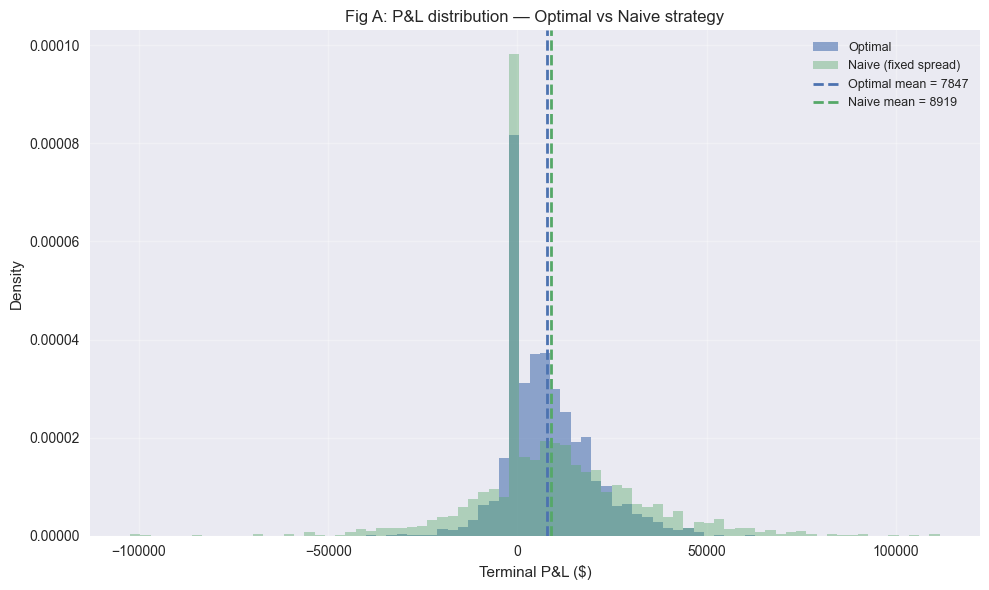


  Strategy          Mean         Std    Sharpe       5%ile      95%ile         Med
  ────────────────────────────────────────────────────────────────────────
  Optimal          +7847       11081     0.708       -5841      +28898       +5729
  Naive            +8919       20784     0.429      -20023      +46825       +4293


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(
    min(res_opt["pnl"].min(), res_naive["pnl"].min()),
    max(res_opt["pnl"].max(), res_naive["pnl"].max()),
    80)

ax.hist(res_opt["pnl"], bins=bins, alpha=0.6, density=True,
        label="Optimal", color="C0")
ax.hist(res_naive["pnl"], bins=bins, alpha=0.4, density=True,
        label="Naive (fixed spread)", color="C1")
ax.axvline(np.mean(res_opt["pnl"]), color="C0", ls="--", lw=2,
           label=f"Optimal mean = {np.mean(res_opt['pnl']):.0f}")
ax.axvline(np.mean(res_naive["pnl"]), color="C1", ls="--", lw=2,
           label=f"Naive mean = {np.mean(res_naive['pnl']):.0f}")
ax.set_xlabel("Terminal P&L ($)")
ax.set_ylabel("Density")
ax.set_title("Fig A: P&L distribution — Optimal vs Naive strategy")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Summary statistics table
print(f"\n  {'Strategy':<10s}  {'Mean':>10s}  {'Std':>10s}  {'Sharpe':>8s}  "
      f"{'5%ile':>10s}  {'95%ile':>10s}  {'Med':>10s}")
print("  " + "─" * 72)
for name, res in [("Optimal", res_opt), ("Naive", res_naive)]:
    pnl = res["pnl"]
    sharpe = np.mean(pnl) / np.std(pnl) if np.std(pnl) > 0 else 0
    print(f"  {name:<10s}  {np.mean(pnl):>+10.0f}  {np.std(pnl):>10.0f}  {sharpe:>8.3f}  "
          f"{np.percentile(pnl, 5):>+10.0f}  {np.percentile(pnl, 95):>+10.0f}  "
          f"{np.median(pnl):>+10.0f}")


The ODE-derived policy improves risk-adjusted performance and inventory control, even when the raw average P&L is not the highest.

The naive strategy has a slightly higher mean terminal P&L, but its distribution is much more dispersed and exhibits substantially worse downside risk. The optimal strategy produces a more concentrated P&L distribution, consistent with the inventory-risk management objective of Model A.

## 7. Figure B — Sample trajectory

A single trajectory showing how the optimal strategy works in practice:
- **Top**: mid-price $S_t$ (Brownian motion, $S_0 = 0$).
- **Middle**: inventory $n_t$ (step function, jumps at each fill).
- **Bottom**: mark-to-market $\text{MtM}_t = X_t + n_t \cdot \Delta \cdot S_t$.

We pick a trajectory with **median fill activity** (not too active, not too quiet).


Selected trajectory #504:
  Bid fills: 1
  Ask fills: 1
  Terminal inventory: 0 lots
  Terminal P&L: 7148


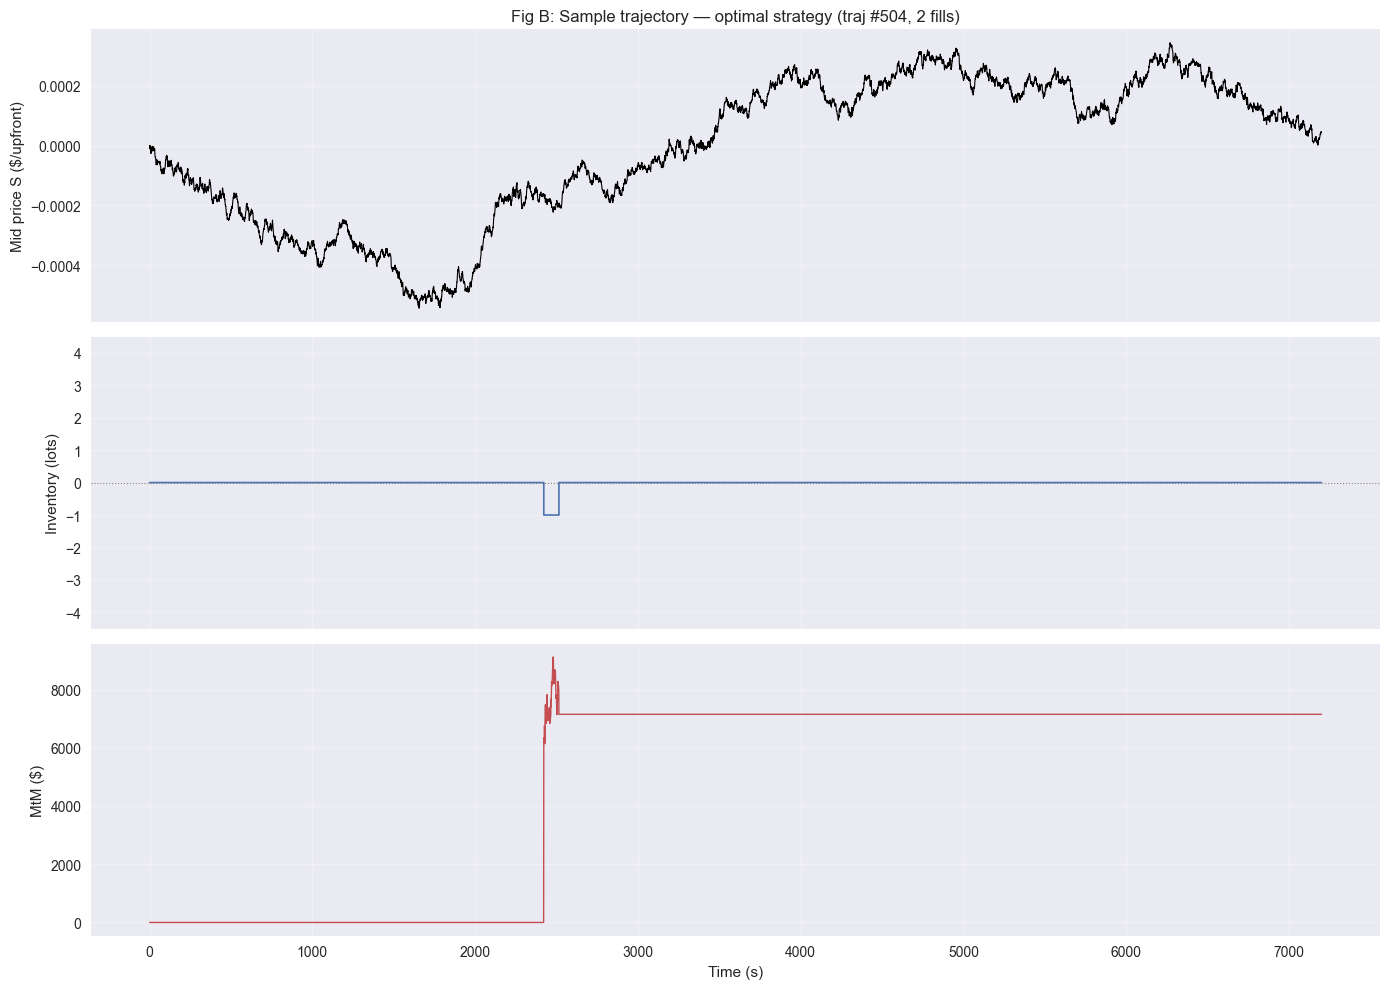

In [20]:
# Pick trajectory with median total fills
idx_med = np.argsort(res_opt["n_bid_fills"] + res_opt["n_ask_fills"])[N_SIM // 2]
fills = res_opt["n_bid_fills"][idx_med] + res_opt["n_ask_fills"][idx_med]

times = res_opt["times"]

print(f"Selected trajectory #{idx_med}:")
print(f"  Bid fills: {res_opt['n_bid_fills'][idx_med]}")
print(f"  Ask fills: {res_opt['n_ask_fills'][idx_med]}")
print(f"  Terminal inventory: {res_opt['inventory'][idx_med, -1]} lots")
print(f"  Terminal P&L: {res_opt['pnl'][idx_med]:.0f}")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Price
ax = axes[0]
ax.plot(times, res_opt["price"][idx_med], color="k", lw=0.8)
ax.set_ylabel("Mid price S ($/upfront)")
ax.set_title(f"Fig B: Sample trajectory — optimal strategy (traj #{idx_med}, {fills} fills)")
ax.grid(alpha=0.3)

# Inventory
ax = axes[1]
ax.step(times, res_opt["inventory"][idx_med], where="post", color="C0", lw=1.2)
ax.set_ylabel("Inventory (lots)")
ax.axhline(0, color="gray", ls=":", lw=0.8)
ax.set_ylim(-Q - 0.5, Q + 0.5)
ax.grid(alpha=0.3)

# MtM
ax = axes[2]
ax.plot(times, res_opt["mtm"][idx_med], color="C2", lw=1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("MtM ($)")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()


This path is representative of the low-fill regime implied by the calibrated parameters: the strategy trades only a few times, briefly carries inventory, and then returns to a flat position. Most of the terminal P&L is therefore generated by spread capture rather than by a large directional inventory bet.

Fill Intensity Calculation
$$
\lambda(\delta) = 9.10 \times 10^{-4} \cdot e^{-1.79 \times 10^{4} \times 1.21 \times 10^{-4}} \approx 1.05 \times 10^{-4}
$$

Expected Fills per Side Over Time
$$
\lambda T = 1.05 \times 10^{-4} \times 7200 \approx 0.76
$$

Selected active trajectory #3:
  Bid fills: 3
  Ask fills: 2
  Total fills: 5
  Terminal inventory: 1 lots
  Terminal P&L: -2433


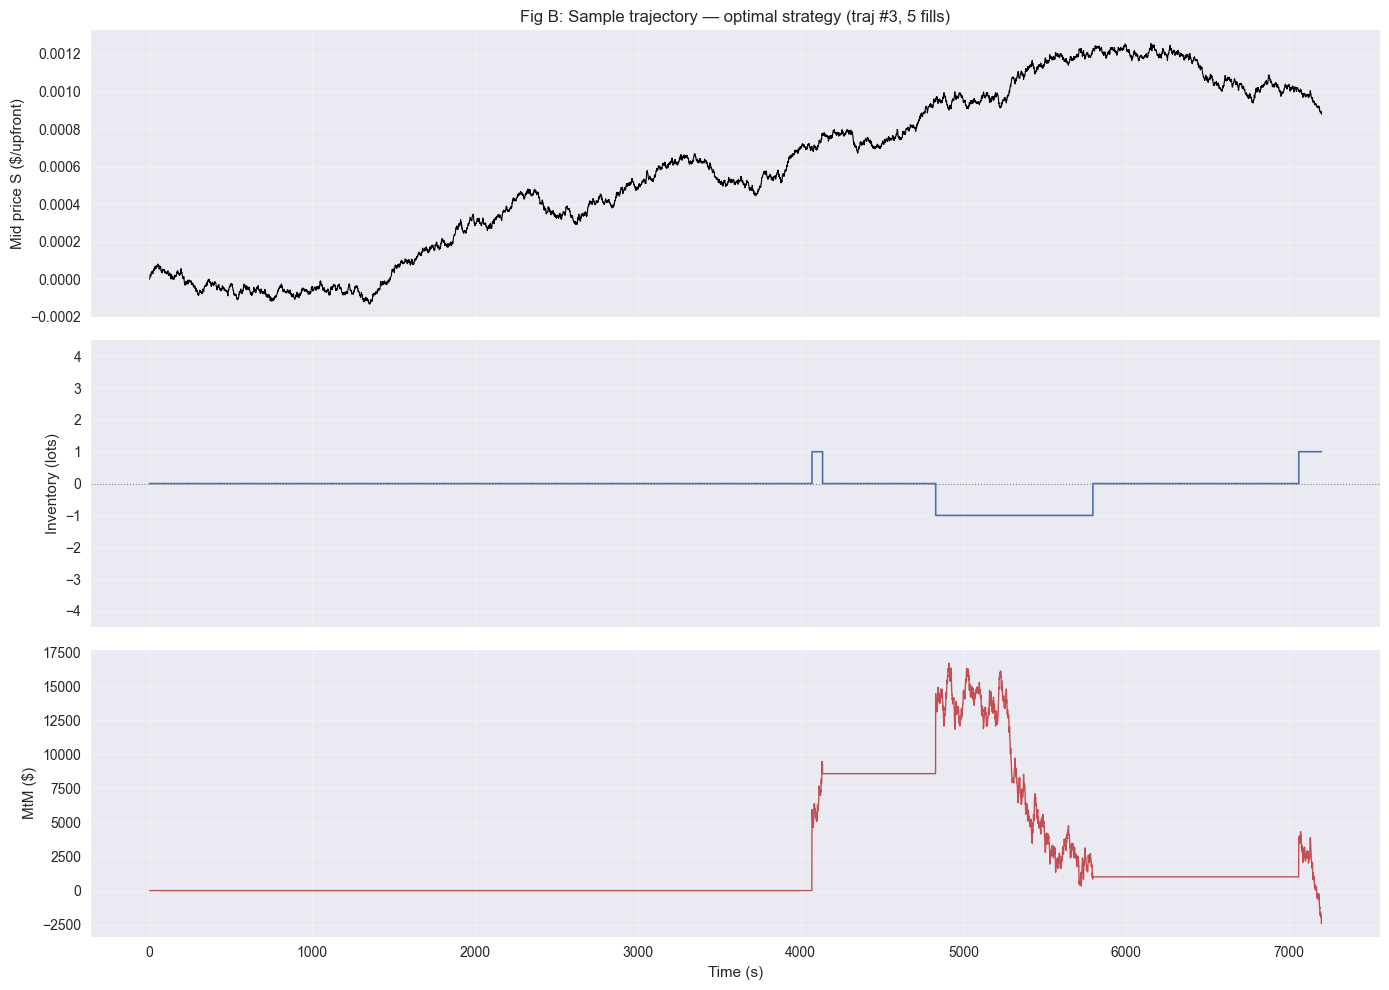

In [21]:
# Total fills per path
total_fills = res_opt["n_bid_fills"] + res_opt["n_ask_fills"]

# Choose a path near the 90th percentile of fill activity
target = np.percentile(total_fills, 90)
idx_active = np.argmin(np.abs(total_fills - target))
fills = res_opt["n_bid_fills"][idx_active] + res_opt["n_ask_fills"][idx_active]

times = res_opt["times"]

print(f"Selected active trajectory #{idx_active}:")
print(f"  Bid fills: {res_opt['n_bid_fills'][idx_active]}")
print(f"  Ask fills: {res_opt['n_ask_fills'][idx_active]}")
print(f"  Total fills: {total_fills[idx_active]}")
print(f"  Terminal inventory: {res_opt['inventory'][idx_active, -1]} lots")
print(f"  Terminal P&L: {res_opt['pnl'][idx_active]:.0f}")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Price
ax = axes[0]
ax.plot(times, res_opt["price"][idx_active], color="k", lw=0.8)
ax.set_ylabel("Mid price S ($/upfront)")
ax.set_title(f"Fig B: Sample trajectory — optimal strategy (traj #{idx_active}, {fills} fills)")
ax.grid(alpha=0.3)

# Inventory
ax = axes[1]
ax.step(times, res_opt["inventory"][idx_active], where="post", color="C0", lw=1.2)
ax.set_ylabel("Inventory (lots)")
ax.axhline(0, color="gray", ls=":", lw=0.8)
ax.set_ylim(-Q - 0.5, Q + 0.5)
ax.grid(alpha=0.3)

# MtM
ax = axes[2]
ax.plot(times, res_opt["mtm"][idx_active], color="C2", lw=1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("MtM ($)")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

Selected active trajectory #261:
  Bid fills: 5
  Ask fills: 5
  Total fills: 10
  Terminal inventory: 0 lots
  Terminal P&L: 39537


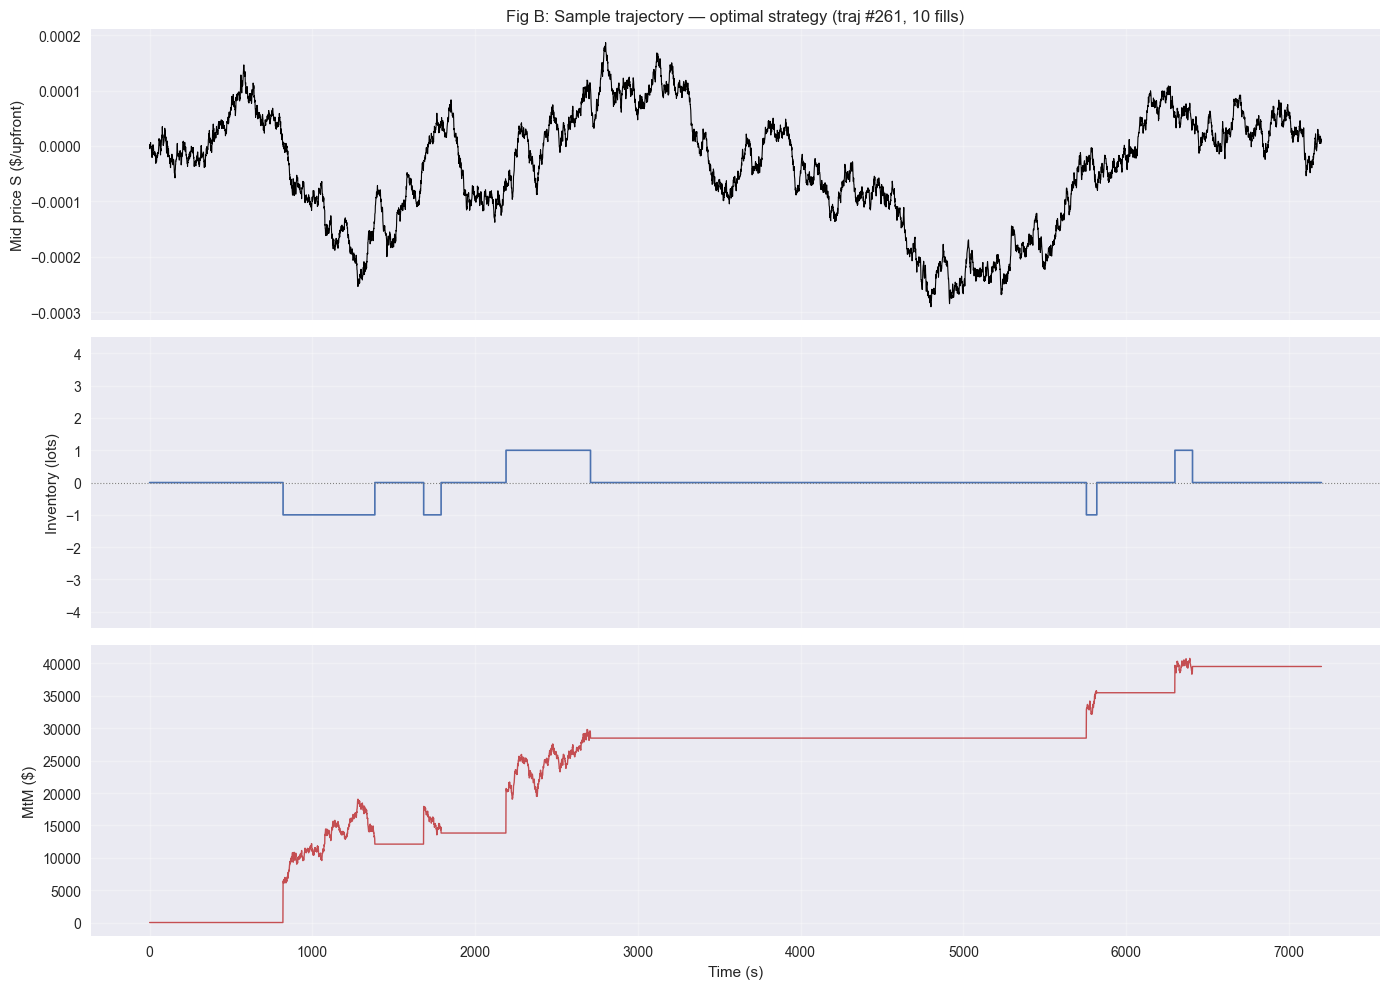

In [22]:
# Total fills per path
total_fills = res_opt["n_bid_fills"] + res_opt["n_ask_fills"]

# Choose a path near the 90th percentile of fill activity
idx_active = np.argmax(total_fills)
fills = res_opt["n_bid_fills"][idx_active] + res_opt["n_ask_fills"][idx_active]

times = res_opt["times"]

print(f"Selected active trajectory #{idx_active}:")
print(f"  Bid fills: {res_opt['n_bid_fills'][idx_active]}")
print(f"  Ask fills: {res_opt['n_ask_fills'][idx_active]}")
print(f"  Total fills: {total_fills[idx_active]}")
print(f"  Terminal inventory: {res_opt['inventory'][idx_active, -1]} lots")
print(f"  Terminal P&L: {res_opt['pnl'][idx_active]:.0f}")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Price
ax = axes[0]
ax.plot(times, res_opt["price"][idx_active], color="k", lw=0.8)
ax.set_ylabel("Mid price S ($/upfront)")
ax.set_title(f"Fig B: Sample trajectory — optimal strategy (traj #{idx_active}, {fills} fills)")

ax.grid(alpha=0.3)

# Inventory
ax = axes[1]
ax.step(times, res_opt["inventory"][idx_active], where="post", color="C0", lw=1.2)
ax.set_ylabel("Inventory (lots)")
ax.axhline(0, color="gray", ls=":", lw=0.8)
ax.set_ylim(-Q - 0.5, Q + 0.5)
ax.grid(alpha=0.3)

# MtM
ax = axes[2]
ax.plot(times, res_opt["mtm"][idx_active], color="C2", lw=1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("MtM ($)")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

The three trajectories above illustrate how the optimal strategy behaves under different levels of market activity.

**Low-activity regime (trajectory #504).**  
In this path the strategy receives very few fills. Inventory remains close to zero almost the entire time, and the mark-to-market P&L evolves only when a trade occurs. This behaviour is expected given the relatively low arrival intensities implied by the calibrated parameters.

**Moderately active regime (trajectory #3).**  
This trajectory shows several fills and temporary inventory imbalances. The inventory fluctuates between positive and negative values as trades occur on both sides of the book. The mark-to-market P&L becomes more volatile because the strategy carries inventory for longer periods and is therefore exposed to price movements.

**Active but controlled regime (trajectory #261).**  
Here the strategy trades multiple times but still keeps inventory relatively close to zero. After temporary deviations, inventory tends to revert toward the neutral position. This behaviour reflects the inventory-dependent quote skewing derived from the ODE solution.

**Key takeaway :**

Across these trajectories, the optimal strategy demonstrates its intended behaviour:

- inventory deviations remain small and temporary,
- positions are gradually unwound through asymmetric quoting,
- most profits arise from repeated spread capture rather than persistent directional exposure.

This confirms that the ODE-derived quotes successfully implement **inventory mean reversion**, which is the central mechanism of the optimal market-making strategy.

## 8. Figure C — Inventory control over time

The **key advantage** of the optimal strategy is inventory control. We plot:
- $\mathbb{E}[\lvert n_t \rvert]$ — mean absolute inventory (how far from flat, on average).
- $\text{std}(n_t)$ — inventory dispersion across paths.

The optimal strategy should keep both metrics **lower** than the naive strategy, because it **skews quotes** to mean-revert toward $n = 0$.


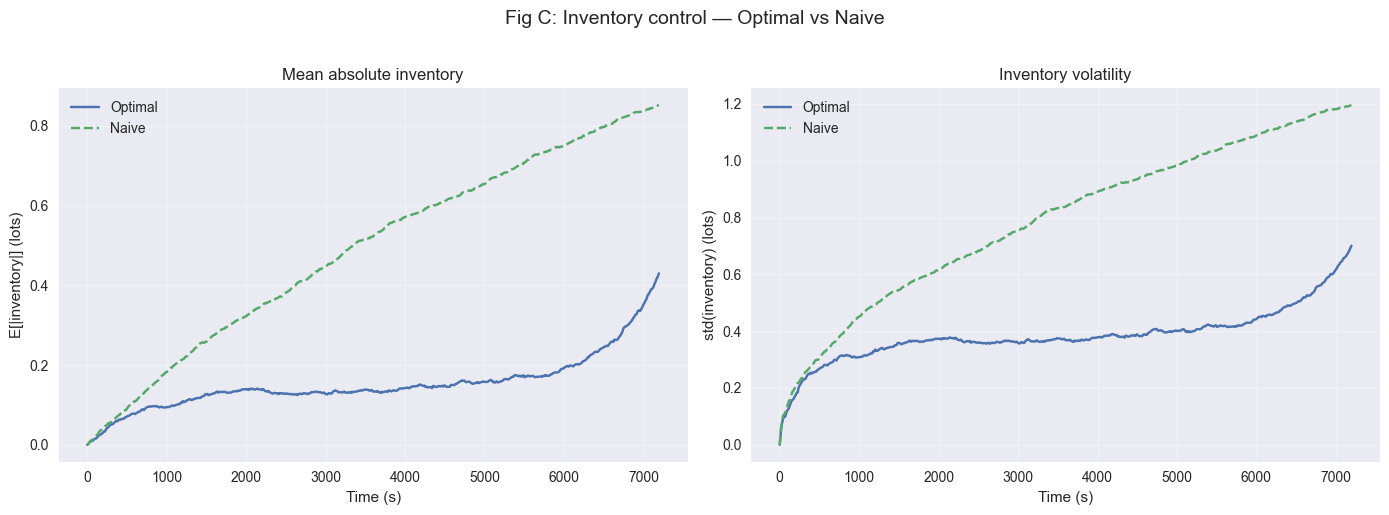


  Strategy      E[|n_T|]    std(n_T)    P(n_T=0)
  ────────────────────────────────────────────
  Optimal           0.43        0.70      60.0%
  Naive             0.85        1.20      37.9%


In [9]:
inv_opt = res_opt["inventory"].astype(float)
inv_naive = res_naive["inventory"].astype(float)

# Subsample for plotting speed
step = max(1, len(times) // 500)
t_sub = times[::step]
mean_abs_opt = np.mean(np.abs(inv_opt[:, ::step]), axis=0)
std_opt = np.std(inv_opt[:, ::step], axis=0)
mean_abs_naive = np.mean(np.abs(inv_naive[:, ::step]), axis=0)
std_naive = np.std(inv_naive[:, ::step], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(t_sub, mean_abs_opt, label="Optimal", color="C0")
ax.plot(t_sub, mean_abs_naive, label="Naive", color="C1", ls="--")
ax.set_xlabel("Time (s)")
ax.set_ylabel("E[|inventory|] (lots)")
ax.set_title("Mean absolute inventory")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(t_sub, std_opt, label="Optimal", color="C0")
ax.plot(t_sub, std_naive, label="Naive", color="C1", ls="--")
ax.set_xlabel("Time (s)")
ax.set_ylabel("std(inventory) (lots)")
ax.set_title("Inventory volatility")
ax.legend()
ax.grid(alpha=0.3)

fig.suptitle("Fig C: Inventory control — Optimal vs Naive", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Report final inventory stats
print(f"\n  {'Strategy':<10s}  {'E[|n_T|]':>10s}  {'std(n_T)':>10s}  {'P(n_T=0)':>10s}")
print("  " + "─" * 44)
for name, inv in [("Optimal", inv_opt), ("Naive", inv_naive)]:
    nT = inv[:, -1]
    print(f"  {name:<10s}  {np.mean(np.abs(nT)):>10.2f}  {np.std(nT):>10.2f}  "
          f"{np.mean(nT == 0):>9.1%}")


The optimal strategy keeps inventory much closer to zero throughout the trading horizon. This is the central practical benefit of the ODE-derived quotes: by skewing bid and ask prices as a function of inventory, the strategy induces mean reversion of inventory and reduces exposure to price risk.

The optimal strategy's main advantage is **not** higher expected P&L — it's **risk reduction**. By skewing quotes with inventory, it:
- Mean-reverts inventory toward 0.
- Reduces P&L variance (less exposure to adverse price moves).
- Achieves a better **risk-adjusted** return (Sharpe ratio).

This validates the ODE solution from Notebooks 01–03: the theoretical optimal quotes genuinely improve risk-adjusted performance when deployed in simulation.


---

# Appendices — Additional diagnostics

*The sections below are not in the original script. They add fill analysis, CARA utility comparison, convergence checks, and deeper trajectory visualization.*


## A.1 Fill statistics

How many fills does each strategy get? The optimal strategy quotes wider when inventory is extreme, which may reduce fill rates.


In [10]:
print(f"  {'Strategy':<10s}  {'E[bid fills]':>14s}  {'E[ask fills]':>14s}  "
      f"{'E[total fills]':>16s}  {'Fill asymmetry':>16s}")
print("  " + "─" * 74)

for name, res in [("Optimal", res_opt), ("Naive", res_naive)]:
    bf = res["n_bid_fills"]
    af = res.get("n_ask_fills", np.zeros(N_SIM))
    # naive may not have separate fill counts — total fills from inventory changes
    if "n_ask_fills" not in res:
        total = np.sum(np.abs(np.diff(res["inventory"], axis=1)), axis=1)
        print(f"  {name:<10s}  {'—':>14s}  {'—':>14s}  "
              f"{np.mean(total):>16.1f}  {'—':>16s}")
    else:
        asym = np.mean(bf) - np.mean(af)
        print(f"  {name:<10s}  {np.mean(bf):>14.1f}  {np.mean(af):>14.1f}  "
              f"{np.mean(bf+af):>16.1f}  {asym:>+16.1f}")

print("\nNote: the optimal strategy should have roughly equal bid/ask fills")
print("(by symmetry, starting at n=0 with symmetric parameters).")


  Strategy      E[bid fills]    E[ask fills]    E[total fills]    Fill asymmetry
  ──────────────────────────────────────────────────────────────────────────
  Optimal                1.4             1.3               2.7              +0.0
  Naive                  0.7             0.7               1.5              -0.0

Note: the optimal strategy should have roughly equal bid/ask fills
(by symmetry, starting at n=0 with symmetric parameters).


Optimal total fills: 2.7
Naive total fills: 1.5
At first glance, this may seem surprising because one might expect the inventory-aware strategy to quote wider and therefore fill less. The optimal strategy does not uniformly quote wider than the naive one. Instead, it dynamically skews quotes depending on inventory. As a result, it can sometimes generate more total fills while still reducing inventory risk and overall P&L volatility.

## A.2 CARA utility comparison

The paper's Model A maximises $\mathbb{E}[-e^{-\gamma \cdot \text{P\&L}}]$, not $\mathbb{E}[\text{P\&L}]$. So the proper comparison is the **certainty equivalent**:

$$\text{CE} = -\frac{1}{\gamma} \ln\!\left(\frac{1}{N_{\text{sim}}} \sum_{i=1}^{N_{\text{sim}}} e^{-\gamma \cdot \text{P\&L}_i}\right)$$

This penalises variance and tail risk — exactly what the optimal strategy targets.


In [11]:

def certainty_equivalent(pnl, gamma):
    """CARA certainty equivalent: CE = -(1/gamma) ln E[exp(-gamma*PnL)]."""
    # Use log-sum-exp trick for numerical stability
    max_val = np.max(-gamma * pnl)
    log_E = max_val + np.log(np.mean(np.exp(-gamma * pnl - max_val)))
    return -log_E / gamma

ce_opt = certainty_equivalent(res_opt["pnl"], GAMMA)
ce_naive = certainty_equivalent(res_naive["pnl"], GAMMA)

print(f"  CARA certainty equivalent (γ = {GAMMA}):")
print(f"    Optimal: CE = {ce_opt:+.0f} $")
print(f"    Naive:   CE = {ce_naive:+.0f} $")
print(f"    Gain:    {ce_opt - ce_naive:+.0f} $ ({(ce_opt-ce_naive)/abs(ce_naive):.1%})")
print(f"\n  For comparison, mean P&L:")
print(f"    Optimal: {np.mean(res_opt['pnl']):+.0f} $")
print(f"    Naive:   {np.mean(res_naive['pnl']):+.0f} $")
print(f"\n  The CE gap is wider than the mean-P&L gap because CE penalises variance.")


  CARA certainty equivalent (γ = 6e-05):
    Optimal: CE = +4557 $
    Naive:   CE = -10474 $
    Gain:    +15031 $ (143.5%)

  For comparison, mean P&L:
    Optimal: +7847 $
    Naive:   +8919 $

  The CE gap is wider than the mean-P&L gap because CE penalises variance.


## A.3 Terminal inventory distribution

The optimal strategy should end up closer to flat ($n_T = 0$) more often.


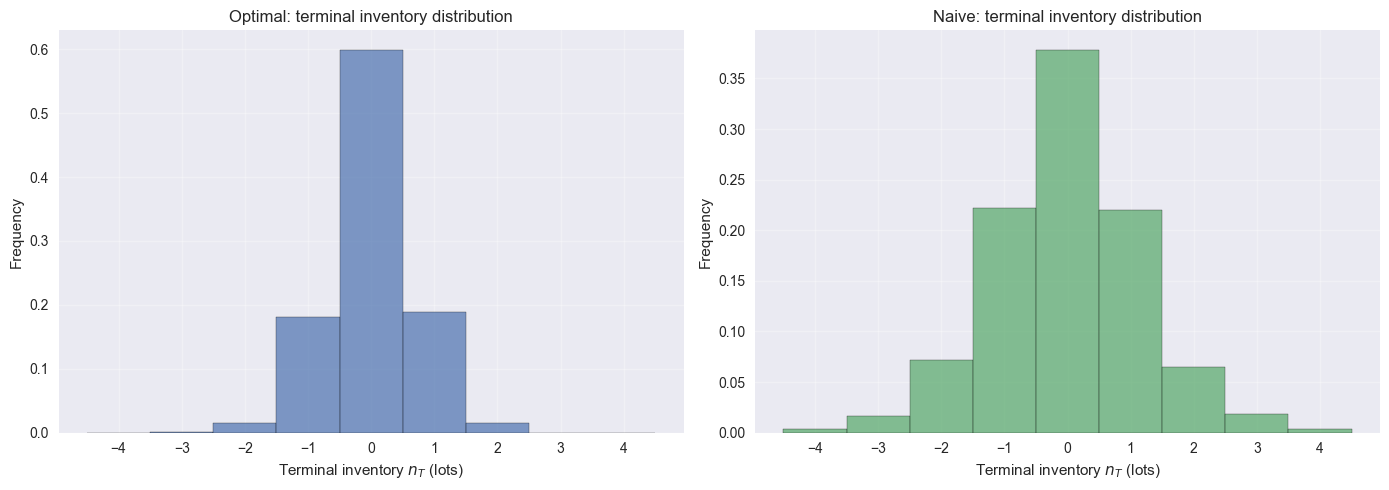

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, inv, name in [(axes[0], res_opt["inventory"][:, -1], "Optimal"),
                       (axes[1], res_naive["inventory"][:, -1], "Naive")]:
    bins = np.arange(-Q - 0.5, Q + 1.5, 1)
    ax.hist(inv, bins=bins, density=True, color="C0" if name == "Optimal" else "C1",
            alpha=0.7, edgecolor="k")
    ax.set_xlabel("Terminal inventory $n_T$ (lots)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{name}: terminal inventory distribution")
    ax.set_xticks(range(-Q, Q + 1))
    ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()


The terminal inventory distribution of the optimal strategy is much more concentrated around zero. This confirms that the policy is not merely changing expected P&L, but actively controlling residual inventory at the end of the horizon.

## A.4 Convergence check — mean P&L vs $N_{\text{sim}}$

Is $N_{\text{sim}} = 2000$ enough? We plot the running mean P&L as a function of the number of paths to check convergence.


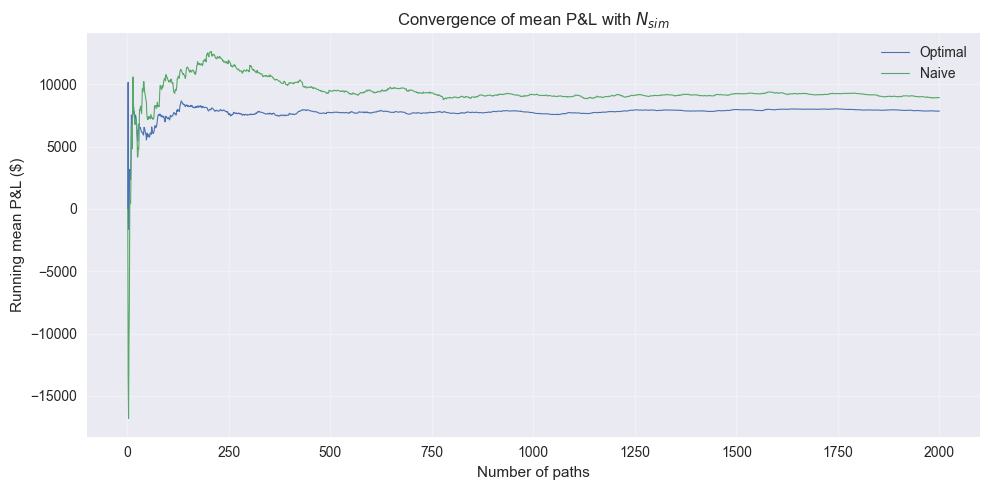

  Optimal: MC std error on mean = ±248 $  (95% CI: [+7361, +8332])
  Naive: MC std error on mean = ±465 $  (95% CI: [+8008, +9829])


In [13]:

fig, ax = plt.subplots(figsize=(10, 5))

for name, res, color in [("Optimal", res_opt, "C0"), ("Naive", res_naive, "C1")]:
    pnl = res["pnl"]
    running_mean = np.cumsum(pnl) / np.arange(1, len(pnl) + 1)
    ax.plot(range(1, len(pnl) + 1), running_mean, color=color, lw=0.8, label=name)

ax.set_xlabel("Number of paths")
ax.set_ylabel("Running mean P&L ($)")
ax.set_title("Convergence of mean P&L with $N_{sim}$")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Monte Carlo standard error
for name, res in [("Optimal", res_opt), ("Naive", res_naive)]:
    se = np.std(res["pnl"]) / np.sqrt(N_SIM)
    print(f"  {name}: MC std error on mean = ±{se:.0f} $  "
          f"(95% CI: [{np.mean(res['pnl'])-1.96*se:+.0f}, {np.mean(res['pnl'])+1.96*se:+.0f}])")


## A.5 Optimal vs Naive — same price path, different inventories

Using the same trajectory index as Fig B, we compare how the two strategies manage inventory on the **same** price path.


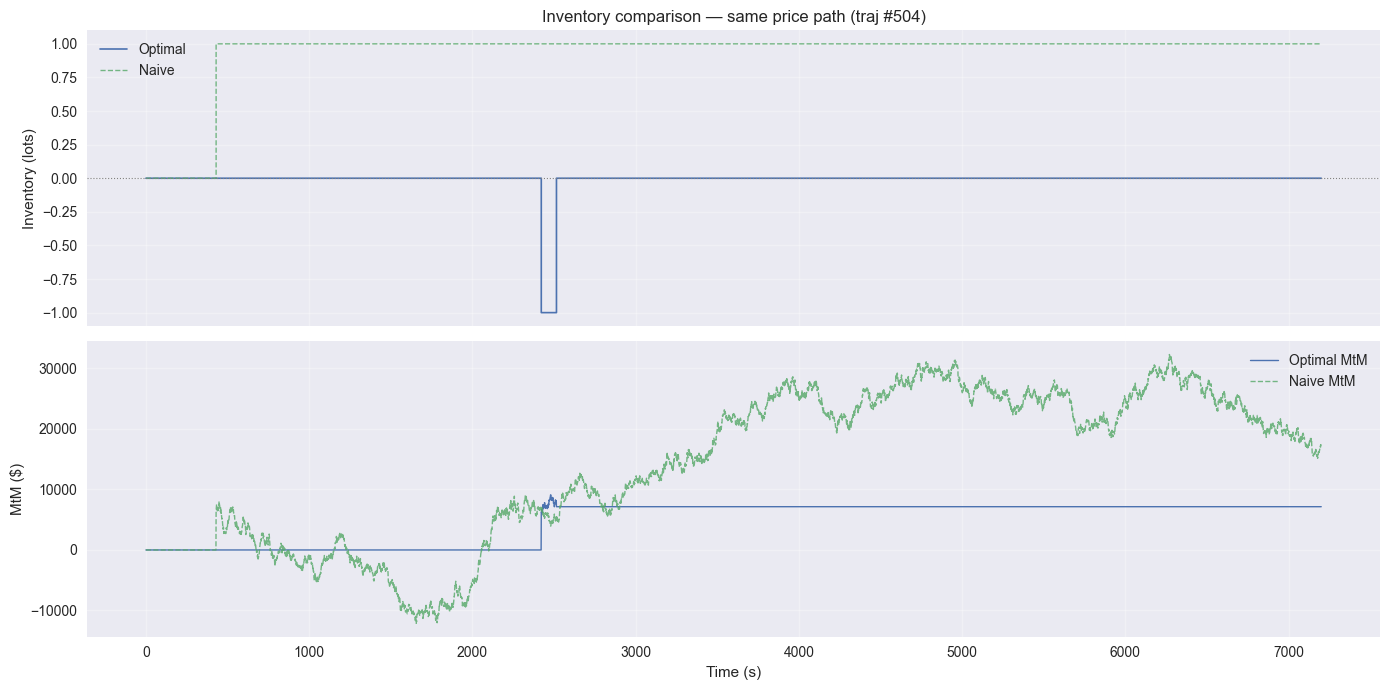

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.step(times, res_opt["inventory"][idx_med], where="post", color="C0", lw=1.2,
        label="Optimal")
ax.step(times, res_naive["inventory"][idx_med], where="post", color="C1", lw=1.0,
        ls="--", label="Naive", alpha=0.8)
ax.set_ylabel("Inventory (lots)")
ax.set_title(f"Inventory comparison — same price path (traj #{idx_med})")
ax.axhline(0, color="gray", ls=":", lw=0.8)
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(times, res_opt["mtm"][idx_med], color="C0", lw=1, label="Optimal MtM")
ax.plot(times, res_naive["mtm"][idx_med], color="C1", lw=1, ls="--",
        label="Naive MtM", alpha=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("MtM ($)")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()


On the same underlying price path, the naive strategy keeps a non-zero inventory for much longer, which mechanically amplifies mark-to-market fluctuations. The optimal strategy unwinds inventory faster, thereby reducing directional exposure.

## A.6 P&L decomposition

Terminal P&L = $X_T + n_T \cdot \Delta \cdot S_T$

- $X_T$ = **cash** component (accumulated from fills).
- $n_T \cdot \Delta \cdot S_T$ = **inventory mark** (unrealised, depends on final price).

The optimal strategy should have lower variance on the inventory-mark component.


<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_22209/3461891800.py:8: SyntaxWarning: invalid escape sequence '\$'
  ax.set_xlabel("Cash $X_T$ (\$)")
/var/folders/th/b_cdn0h107lcl7b1cp9xd7zc0000gn/T/ipykernel_22209/3461891800.py:9: SyntaxWarning: invalid escape sequence '\$'
  ax.set_ylabel("Inventory mark $n_T \\cdot \\Delta \\cdot S_T$ (\$)")


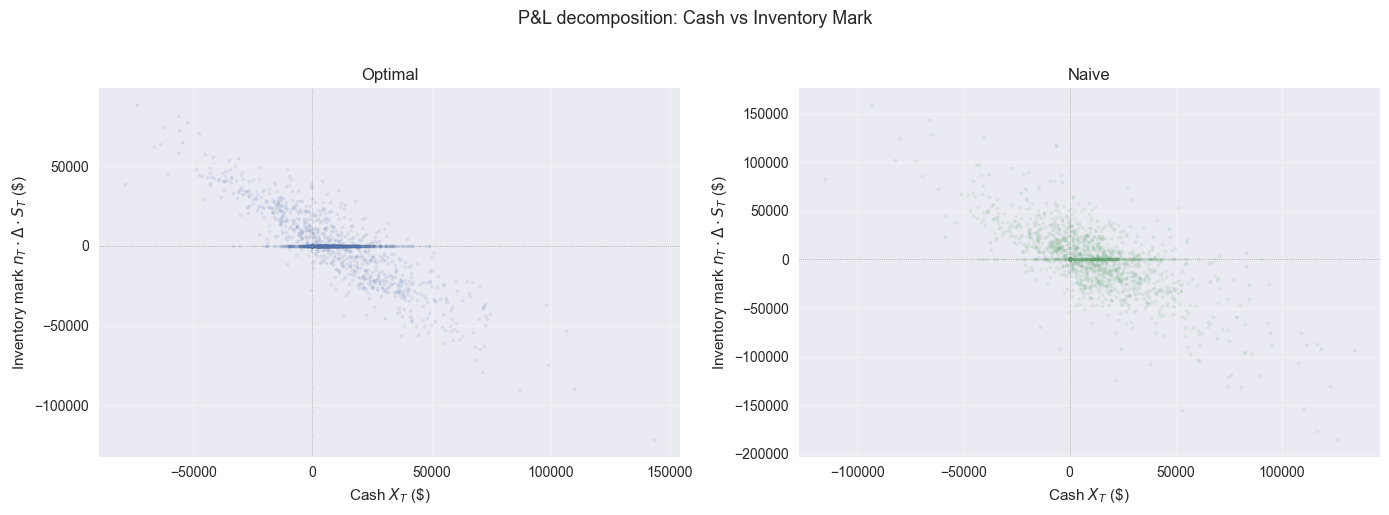

  Optimal:  Var(cash)=3.62e+08  Var(inv_mark)=2.79e+08  Var(P&L)=1.23e+08
  Naive:  Var(cash)=5.18e+08  Var(inv_mark)=7.91e+08  Var(P&L)=4.32e+08


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, name in [(axes[0], res_opt, "Optimal"), (axes[1], res_naive, "Naive")]:
    cash_T = res["cash"][:, -1]
    inv_mark = res["inventory"][:, -1].astype(float) * IG["Delta"] * res["price"][:, -1]
    
    ax.scatter(cash_T, inv_mark, alpha=0.1, s=5, color="C0" if name == "Optimal" else "C1")
    ax.set_xlabel("Cash $X_T$ (\$)")
    ax.set_ylabel("Inventory mark $n_T \\cdot \\Delta \\cdot S_T$ (\$)")
    ax.set_title(f"{name}")
    ax.axhline(0, color="gray", ls=":", lw=0.5)
    ax.axvline(0, color="gray", ls=":", lw=0.5)
    ax.grid(alpha=0.3)

fig.suptitle("P&L decomposition: Cash vs Inventory Mark", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# Variance decomposition
for name, res in [("Optimal", res_opt), ("Naive", res_naive)]:
    cash_T = res["cash"][:, -1]
    inv_mark = res["inventory"][:, -1].astype(float) * IG["Delta"] * res["price"][:, -1]
    print(f"  {name}:  Var(cash)={np.var(cash_T):.2e}  Var(inv_mark)={np.var(inv_mark):.2e}  "
          f"Var(P&L)={np.var(res['pnl']):.2e}")


The main variance reduction comes from the inventory-mark component $n_T \Delta S_T$. This is precisely where inventory-aware quote skewing matters: the optimal strategy avoids carrying large residual positions into the terminal mark-to-market.